In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys

# Add the project's files to the python path
# file_path = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))  # for .py script
file_path = os.path.dirname(os.path.abspath(''))  # for .ipynb notebook
sys.path.append(file_path)

import hydra
from src.utils import init_config
import torch
from src.transforms import *
from src.utils.widgets import ConfigUI
from src.data import *

## Select your device, experiment, split, and pretrained model

In [2]:
ui = ConfigUI(tasks=['semantic', 'panoptic'])

In [3]:
# Check the user selected values 
print(f"You chose:")
for k, v in ui.values.items():
    print(f"  - {k:<20}: {v}")

You chose:
  - task                : semantic
  - experiment          : dales
  - ckpt                : /users/eleves-b/2022/aziz.bacha/superpoint_transformer/models/spt-2_dales.ckpt
  - ckpt_ezsp_partition : None
  - split               : val
  - mini                : False
  - device              : cuda:0


## Parsing the config files

In [7]:
# Parse the configs using hydra
cfg = init_config(overrides=[
    f"experiment={ui.values['task']}/{ui.values['experiment']}",
    f"ckpt_path={ui.values['ckpt']}",
    f"datamodule.mini={ui.values['mini']}",
    f"++datamodule.pretrained_cnn_ckpt_path={ui.values['ckpt_ezsp_partition'] or 'null'}",  # only needed for EZ-SP models
    f"datamodule.load_full_res_idx={True}",  # only needed for making full-resolution predictions 
    "paths.data_dir=/Data/aziz.bacha/datasets",
])

## Datamodule and model instantiation

In [ ]:
# Instantiate the datamodule
datamodule = hydra.utils.instantiate(cfg.datamodule)
datamodule.prepare_data()
datamodule.setup()

# Pick among train, val, and test datasets
if ui.values['split'] == 'train':
    dataset = datamodule.train_dataset
elif ui.values['split'] == 'val':
    dataset = datamodule.val_dataset
elif ui.values['split'] == 'test':
    dataset = datamodule.test_dataset
else:
    raise ValueError(f"Unknown split '{ui.values['split']}'")

# Print a summary of the datasets' classes
dataset.print_classes()

# Instantiate the model
model = hydra.utils.instantiate(cfg.model)

# Load pretrained weights from a checkpoint file
if ui.values['ckpt'] is not None:
    model = model._load_from_checkpoint(
        cfg.ckpt_path,
        pretrained_cnn_ckpt_path=cfg.datamodule.pretrained_cnn_ckpt_path)

# Move model to selected device
model = model.eval().to(ui.values['device'])

Processing...


  0%|          | 0/99 [00:00<?, ?it/s]

Done!
Processing...


  0%|          | 0/261 [00:00<?, ?it/s]

Done!
Lightning automatically upgraded your loaded checkpoint from v1.8.4.post0 to v2.4.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../models/spt-2_dales.ckpt`
⚠️ No `__version__` found in checkpoint metadata.
This means the checkpoint was saved with a version of the code prior to 3.0.0.
Setting the version 2.1.0, so that the official weights of SPT and SPC are compatible.
If you have weights from version 2.2.0, please use the migration script to set the version to 3.0.0.
(see: src/utils/backwards_compatibility/add_version_to_checkpoint.py and CHANGELOG.md for more details)
⚠️ No `commit_hash` found in checkpoint metadata.
This means the checkpoint was saved with a version of the code prior to 3.0.0.
Setting the commit hash to unknown.


0   Ground               stuff
1   Vegetation           stuff
2   Cars                 thing
3   Trucks               thing
4   Power lines          thing
5   Fences               thing
6   Poles                thing
7   Buildings            thing
8   Unknown              void


## Hierarchical partition loading and inference

In [ ]:
model.net.store_features = True

# Load the first dataset item
nag = dataset[0]

nag = dataset.on_device_transform(nag.to(ui.values['device']))

# Inference
with torch.no_grad():
    output = model(nag)

# Compute the level-0 (voxel-wise) semantic segmentation predictions 
nag[0].semantic_pred = output.voxel_semantic_pred(super_index=nag[0].super_index)

#compute the level-0 panoptic segmentation predictions, if 
if ui.values['task'] == 'panoptic':
    vox_y, vox_index, vox_obj_pred = output.voxel_panoptic_pred(super_index=nag[0].super_index)
    nag[0].obj_pred = vox_obj_pred

In [ ]:
# Compute the full-resolution semantic prediction 
raw_semseg_y = output.full_res_semantic_pred(
    super_index_level0_to_level1=nag[0].super_index,
    sub_level0_to_raw=nag[0].sub)

# full-resolution panoptic prediction. 
if ui.values['task'] == 'panoptic':
    raw_pano_y, raw_index, raw_obj_pred = output.full_res_panoptic_pred(
        super_index_level0_to_level1=nag[0].super_index, 
        sub_level0_to_raw=nag[0].sub)

## Visualizing an entire tile

In [ ]:
# Visualize the hierarchical partition
nag.show( 
    class_names=dataset.class_names,
    class_colors=dataset.class_colors,
    stuff_classes=dataset.stuff_classes,
    num_classes=dataset.num_classes,
    max_points=100000
)

## Selecting a portion of the hierarchical partition

In [70]:
# Predefined radius and center locations for each dataset
# Feel free to modify these values
center = nag[0].pos.mean(dim=0).view(1, -1)
if 'dales' in ui.values['experiment']:
    radius = 10
elif 'kitti360' in ui.values['experiment']:
    radius = 10
elif 'scannet' in ui.values['experiment']:
    radius = 10
elif 's3dis' in ui.values['experiment']:
    radius = 3
else:
    radius = 3

In [ ]:
# Visualize the sample
nag.show(
    radius=radius,
    center=center,
    class_names=dataset.class_names,
    class_colors=dataset.class_colors,
    stuff_classes=dataset.stuff_classes,
    num_classes=dataset.num_classes,
    max_points=100000
)

## Visualizing random samples centered on a class of interest

In [ ]:
datamodule.train_dataset.show_examples(7, radius=radius, max_examples=5)

## Visualizing the superpoint graphs

In [ ]:
# Visualize the sample
nag.show(
    radius=radius,
    center=center,
    class_names=dataset.class_names,
    class_colors=dataset.class_colors,
    stuff_classes=dataset.stuff_classes,
    num_classes=dataset.num_classes,
    max_points=100000, 
    centroids=True, 
    h_edge=True, 
    h_edge_width=2
)

## Side-by-side visualization mode

In [ ]:
# Visualize the sample
nag.show(
    figsize=1000,
    radius=radius,
    center=center,
    class_names=dataset.class_names,
    class_colors=dataset.class_colors,
    stuff_classes=dataset.stuff_classes,
    num_classes=dataset.num_classes,
    max_points=100000, 
    centroids=True, 
    v_edge=True, 
    v_edge_width=2, 
    gap=[0, 4, 8]
)

In [68]:
print(f"Number of tiles in dataset: {len(dataset)}")

Number of tiles in dataset: 99


## Per class IoU

In [ ]:
from tqdm import tqdm
import numpy as np
from src.datasets.dales import CLASS_NAMES as DALES_CLASS_NAMES
all_preds = []
all_gt = []

for i in tqdm(range(len(dataset))):
    
    nag = dataset[i]
    nag = nag.cuda()
    nag = dataset.on_device_transform(nag.to(ui.values['device']))
    
    model.eval()
    with torch.no_grad():
        output = model(nag)
    
    preds = output.semantic_pred().cpu().numpy()
    gt = nag[1].y.cpu().argmax(dim=1).numpy()
    
    all_preds.append(preds)
    all_gt.append(gt)
    
    del nag, output
    torch.cuda.empty_cache()

all_preds = np.concatenate(all_preds)
all_gt = np.concatenate(all_gt)

In [32]:
num_classes = len(DALES_CLASS_NAMES)
valid_mask = all_gt < num_classes

gt_valid = all_gt[valid_mask]
pred_valid = all_preds[valid_mask]

print(f"Total superpoints evaluated: {len(gt_valid):,}")

print("Per-class IoU at the superpoint level:")
print(f"\n{'Class':<15} | {'IoU':>8} | {'Count':>8}")
print(f"{'-'*40}")
ious = []
for cls_id in range(num_classes):
    intersection = ((pred_valid == cls_id) & (gt_valid == cls_id)).sum()
    union = ((pred_valid == cls_id) | (gt_valid == cls_id)).sum()
    iou = intersection / union if union > 0 else 0.0
    ious.append(iou)
    count = (gt_valid == cls_id).sum()
    print(f"{DALES_CLASS_NAMES[cls_id]:<15} | {iou*100:>7.2f}% | {count:>8,}")

print(f"\nmIoU: {np.mean(ious)*100:.2f}%")

Total superpoints evaluated: 3,918,779
Per-class IoU at the superpoint level:

Class           |      IoU |    Count
----------------------------------------
Ground          |   97.35% | 1,698,643
Vegetation      |   95.45% | 1,509,916
Cars            |   85.82% |   29,006
Trucks          |   49.28% |    4,680
Power lines     |   96.48% |   10,973
Fences          |   59.13% |   25,997
Poles           |   66.91% |    2,815
Buildings       |   96.67% |  636,749
Unknown         |    0.00% |        0

mIoU: 71.90%


In [35]:
from tqdm import tqdm
all_voxel_preds = []
all_voxel_gt = []

for i in tqdm(range(len(dataset))):
    nag = dataset[i]
    nag = nag.cuda()
    nag = dataset.on_device_transform(nag.to(ui.values['device']))
    
    model.eval()
    with torch.no_grad():
        output = model(nag)
    
    # Voxel-level predictions
    voxel_preds = output.voxel_semantic_pred(super_index=nag[0].super_index).cpu().numpy()
    voxel_gt = nag[0].y.cpu().argmax(dim=1).numpy()
    
    all_voxel_preds.append(voxel_preds)
    all_voxel_gt.append(voxel_gt)
    
    del nag, output
    torch.cuda.empty_cache()

all_voxel_preds = np.concatenate(all_voxel_preds)
all_voxel_gt = np.concatenate(all_voxel_gt)

  0%|          | 0/99 [00:00<?, ?it/s]

100%|██████████| 99/99 [00:54<00:00,  1.83it/s]


In [37]:
# =====================================================
# Voxel-level IoU computation
# =====================================================
num_classes = len(DALES_CLASS_NAMES)
valid_mask = all_voxel_gt < num_classes
voxel_gt_valid = all_voxel_gt[valid_mask]
voxel_pred_valid = all_voxel_preds[valid_mask]

print(f"Total voxels evaluated: {len(voxel_gt_valid):,}")
print(f"\n{'Class':<15} | {'IoU':>8} | {'Precision':>10} | {'Recall':>8} | {'Count':>10}")
print(f"{'-'*65}")

ious = []
for cls_id in range(num_classes):
    tp = ((voxel_pred_valid == cls_id) & (voxel_gt_valid == cls_id)).sum()
    fp = ((voxel_pred_valid == cls_id) & (voxel_gt_valid != cls_id)).sum()
    fn = ((voxel_pred_valid != cls_id) & (voxel_gt_valid == cls_id)).sum()
    
    union = tp + fp + fn
    iou = tp / union if union > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    count = (voxel_gt_valid == cls_id).sum()
    
    ious.append(iou)
    print(f"{DALES_CLASS_NAMES[cls_id]:<15} | {iou*100:>7.2f}% | {precision*100:>9.2f}% | {recall*100:>7.2f}% | {count:>10,}")

miou = np.mean(ious) * 100
print(f"\nmIoU (voxel-level): {miou:.2f}%")


Total voxels evaluated: 122,904,790

Class           |      IoU |  Precision |   Recall |      Count
-----------------------------------------------------------------
Ground          |   96.54% |     97.57% |   98.92% | 61,121,833
Vegetation      |   93.29% |     97.79% |   95.30% | 39,036,587
Cars            |   85.39% |     88.38% |   96.19% |    903,030
Trucks          |   49.23% |     64.35% |   67.69% |    139,541
Power lines     |   93.88% |     97.88% |   95.82% |    213,362
Fences          |   53.05% |     58.55% |   84.97% |    573,930
Poles           |   63.80% |     73.84% |   82.43% |     59,816
Buildings       |   96.66% |     98.77% |   97.84% | 20,856,691
Unknown         |    0.00% |      0.00% |    0.00% |          0

mIoU (voxel-level): 70.20%


## Superpoint sizes and purity

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

num_classes = len(DALES_CLASS_NAMES)
valid_mask = all_gt < num_classes
gt_valid = all_gt[valid_mask]
pred_valid = all_preds[valid_mask]

# Superpoint sizes and purity across all tiles
all_sp_sizes = []
all_purities = []
all_purity_sizes = []

for i in tqdm(range(len(dataset))):
    nag = dataset[i]
    
    super_index = nag[0].super_index.cpu().numpy()
    voxel_gt = nag[0].y.cpu().argmax(dim=1).numpy()
    num_sp = nag[1].num_points
    num_cls = num_classes + 1
    
    # Superpoint sizes
    sp_sizes = np.bincount(super_index, minlength=num_sp)
    all_sp_sizes.append(sp_sizes)
    
    # Purity: build histogram of classes per superpoint
    sp_class_counts = np.zeros((num_sp, num_cls), dtype=int)
    np.add.at(sp_class_counts, (super_index, voxel_gt), 1)
    
    sp_total = sp_class_counts.sum(axis=1)
    sp_max = sp_class_counts.max(axis=1)
    
    nonzero = sp_total > 0
    all_purities.append(sp_max[nonzero] / sp_total[nonzero])
    all_purity_sizes.append(sp_total[nonzero])
    
    del nag

all_sp_sizes = np.concatenate(all_sp_sizes)
all_purities = np.concatenate(all_purities)
all_purity_sizes = np.concatenate(all_purity_sizes)

# Filter valid
sizes_valid = all_sp_sizes[valid_mask]
correct = (pred_valid == gt_valid)

100%|██████████| 99/99 [00:07<00:00, 12.92it/s]


In [ ]:
# Size bins
size_bins = [1, 5, 10, 25, 50, 100, 250, 500]
bin_labels = [f'{size_bins[i]}-{size_bins[i+1]-1}' for i in range(len(size_bins)-1)]
bin_labels.append(f'{size_bins[-1]}+')

def get_bin(size):
    for i, threshold in enumerate(size_bins[1:]):
        if size < threshold:
            return i
    return len(size_bins) - 1

sp_bin_idx = np.array([get_bin(s) for s in sizes_valid])

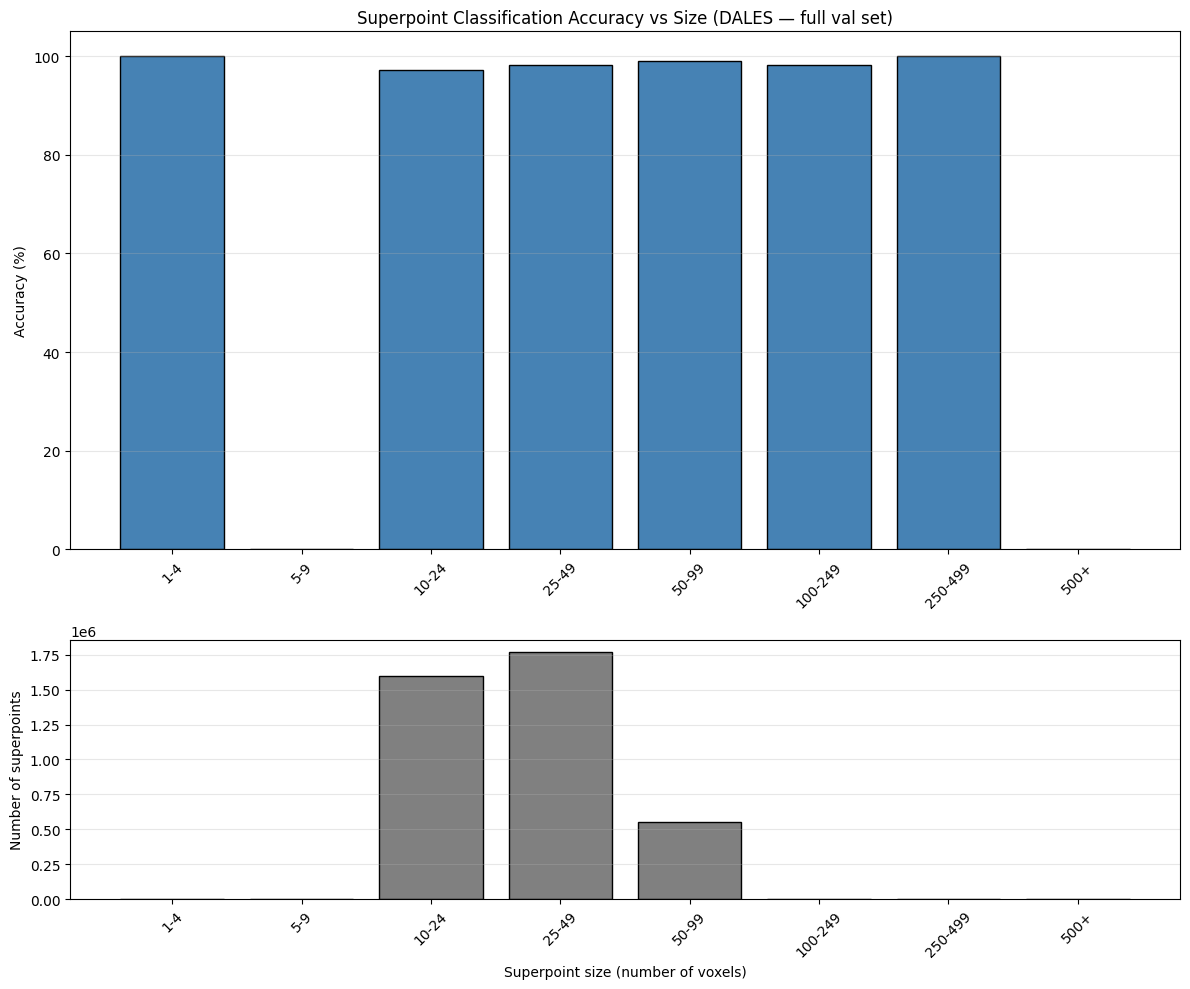


Size bin     |      Count |   Accuracy
----------------------------------------
1-4          |          1 |    100.00%
5-9          |          0 |      0.00%
10-24        |  1,596,098 |     97.23%
25-49        |  1,767,191 |     98.22%
50-99        |    553,934 |     98.94%
100-249      |      1,554 |     98.13%
250-499      |          1 |    100.00%
500+         |          0 |      0.00%


In [ ]:
# Plot 1: Overall accuracy vs superpoint size
overall_acc_per_bin = []
bin_counts = []
for b in range(len(bin_labels)):
    mask = sp_bin_idx == b
    if mask.sum() > 0:
        overall_acc_per_bin.append(correct[mask].mean() * 100)
        bin_counts.append(mask.sum())
    else:
        overall_acc_per_bin.append(0)
        bin_counts.append(0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.bar(range(len(bin_labels)), overall_acc_per_bin, color='steelblue', edgecolor='black')
ax1.set_xticks(range(len(bin_labels)))
ax1.set_xticklabels(bin_labels, rotation=45)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Superpoint Classification Accuracy vs Size (DALES — full val set)')
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(range(len(bin_labels)), bin_counts, color='gray', edgecolor='black')
ax2.set_xticks(range(len(bin_labels)))
ax2.set_xticklabels(bin_labels, rotation=45)
ax2.set_ylabel('Number of superpoints')
ax2.set_xlabel('Superpoint size (number of voxels)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sp_size_vs_accuracy_dales_full.png', dpi=150, bbox_inches='tight')
plt.show()

# Print table
print(f"\n{'Size bin':<12} | {'Count':>10} | {'Accuracy':>10}")
print(f"{'-'*40}")
for b in range(len(bin_labels)):
    print(f"{bin_labels[b]:<12} | {bin_counts[b]:>10,} | {overall_acc_per_bin[b]:>9.2f}%")


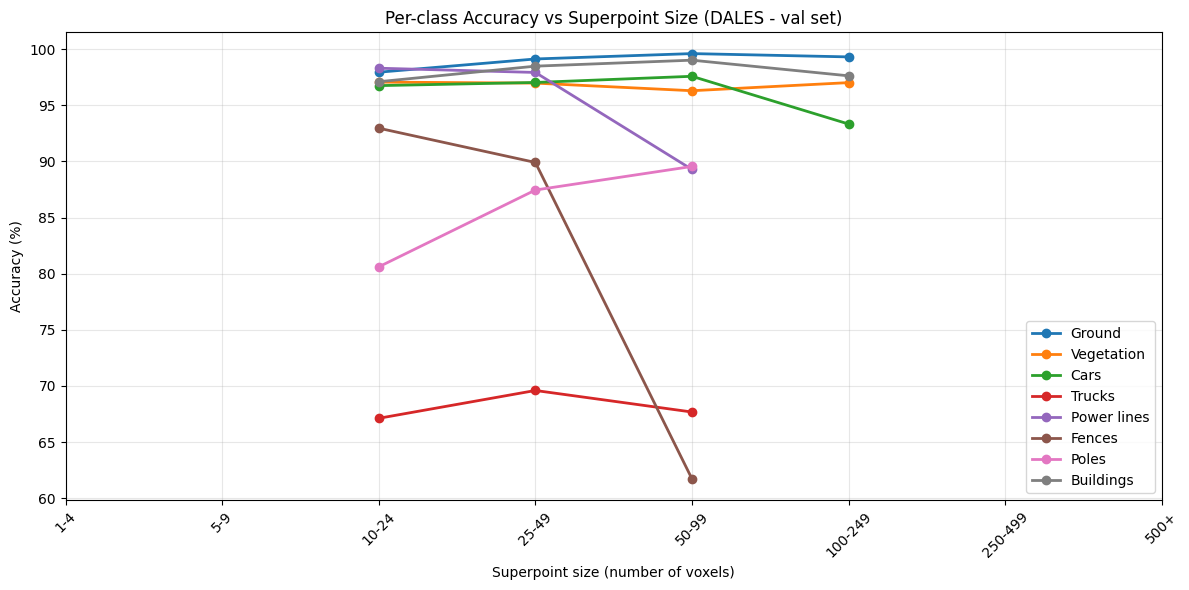

In [ ]:
# Plot 2: Per-class accuracy vs superpoint size
fig, ax = plt.subplots(figsize=(12, 6))

for cls_id in range(num_classes):
    cls_mask = gt_valid == cls_id
    if cls_mask.sum() == 0:
        continue
    acc_per_bin = []
    for b in range(len(bin_labels)):
        mask = (sp_bin_idx == b) & cls_mask
        if mask.sum() > 10:
            acc_per_bin.append(correct[mask].mean() * 100)
        else:
            acc_per_bin.append(np.nan)
    ax.plot(range(len(bin_labels)), acc_per_bin, 'o-', label=DALES_CLASS_NAMES[cls_id], linewidth=2)

ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=45)
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Superpoint size (number of voxels)')
ax.set_title('Per-class Accuracy vs Superpoint Size (DALES - val set)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sp_size_vs_accuracy_perclass_dales_full.png', dpi=150, bbox_inches='tight')
plt.show()


/tmp/ipykernel_888768/1948989024.py:5: RuntimeWarning:

invalid value encountered in divide



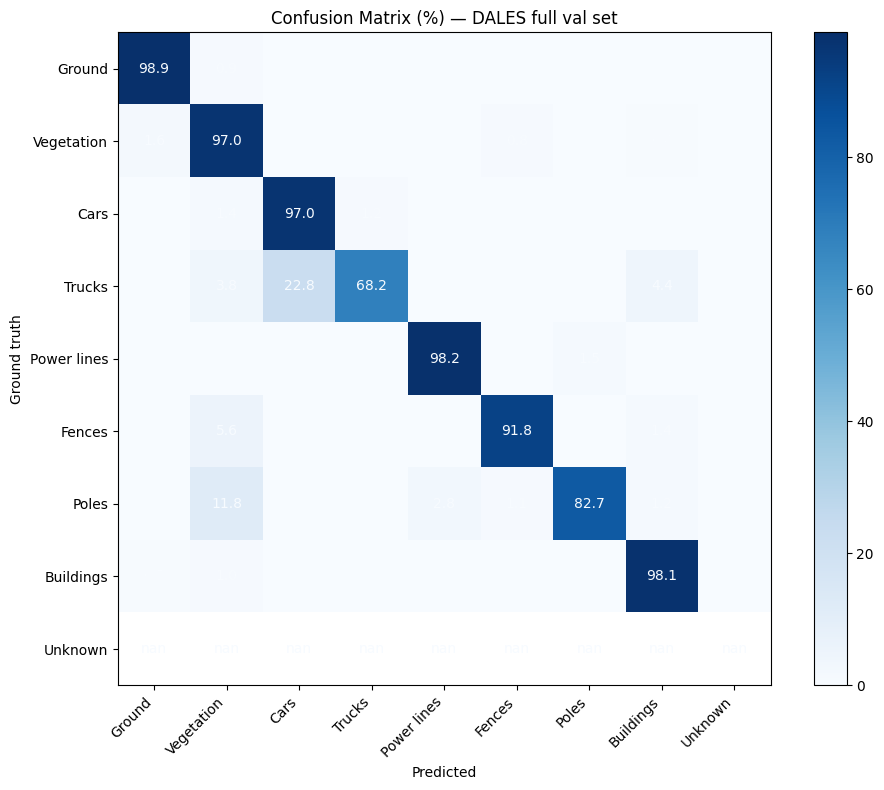

In [ ]:
# Confusion Matrix
cm = confusion_matrix(gt_valid, pred_valid, labels=range(num_classes))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm_norm, display_labels=DALES_CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', values_format='.1f')
ax.set_title('Confusion Matrix (%) — DALES full val set')
ax.set_ylabel('Ground truth')
ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_dales_full.png', dpi=150, bbox_inches='tight')
plt.show()



Purity statistics (full val set):
  Mean purity:   98.43%
  Median purity: 100.00%
  100% pure:     92.1%
  <80% pure:     3.3%


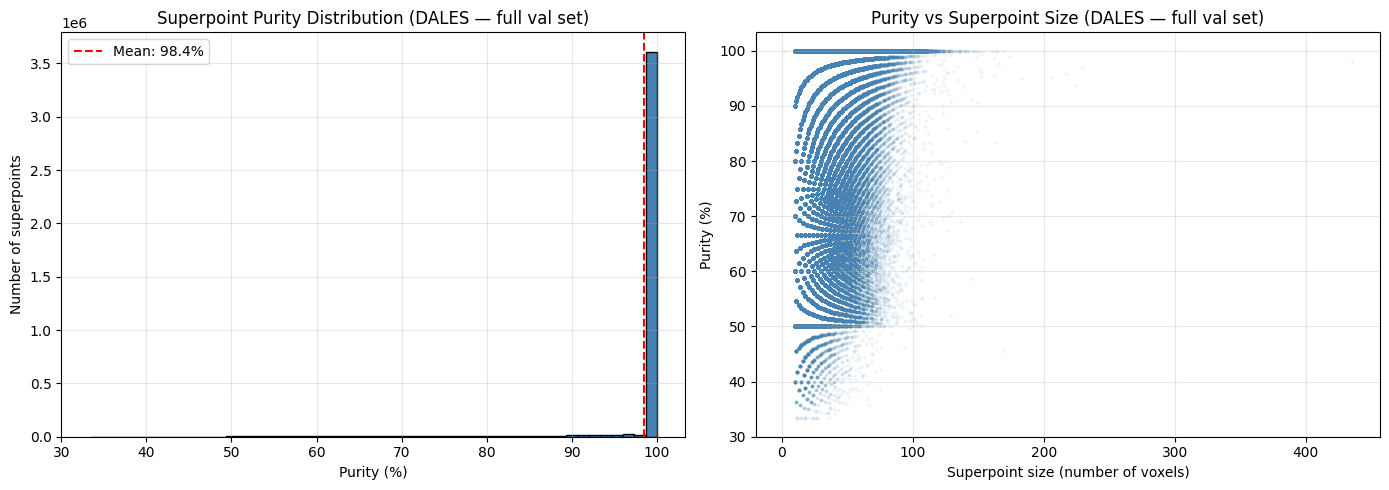

In [ ]:
# Superpoint Purity
print(f"\nPurity statistics (full val set):")
print(f"  Mean purity:   {all_purities.mean()*100:.2f}%")
print(f"  Median purity: {np.median(all_purities)*100:.2f}%")
print(f"  100% pure:     {(all_purities == 1.0).mean()*100:.1f}%")
print(f"  <80% pure:     {(all_purities < 0.8).mean()*100:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(all_purities * 100, bins=50, color='steelblue', edgecolor='black')
ax1.set_xlabel('Purity (%)')
ax1.set_ylabel('Number of superpoints')
ax1.set_title('Superpoint Purity Distribution (DALES — full val set)')
ax1.axvline(all_purities.mean()*100, color='red', linestyle='--', label=f'Mean: {all_purities.mean()*100:.1f}%')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(all_purity_sizes, all_purities * 100, alpha=0.05, s=3, color='steelblue')
ax2.set_xlabel('Superpoint size (number of voxels)')
ax2.set_ylabel('Purity (%)')
ax2.set_title('Purity vs Superpoint Size (DALES — full val set)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('superpoint_purity_dales_full.png', dpi=150, bbox_inches='tight')
plt.show()

  0%|          | 0/99 [00:00<?, ?it/s]

100%|██████████| 99/99 [00:07<00:00, 14.07it/s]



Class           |  Mean purity |  100% pure |  <80% pure |    Count
----------------------------------------------------------------------
Ground          |       97.85% |      88.1% |       4.3% | 1,698,605
Vegetation      |       98.75% |      94.7% |       2.8% | 1,509,856
Cars            |       99.05% |      93.9% |       1.7% |   29,013
Trucks          |       98.87% |      94.0% |       2.4% |    4,678
Power lines     |       99.55% |      98.2% |       1.0% |   10,971
Fences          |       93.76% |      73.4% |      13.7% |   25,990
Poles           |       94.55% |      74.7% |      12.2% |    2,814
Buildings       |       99.37% |      97.4% |       1.4% |  636,852


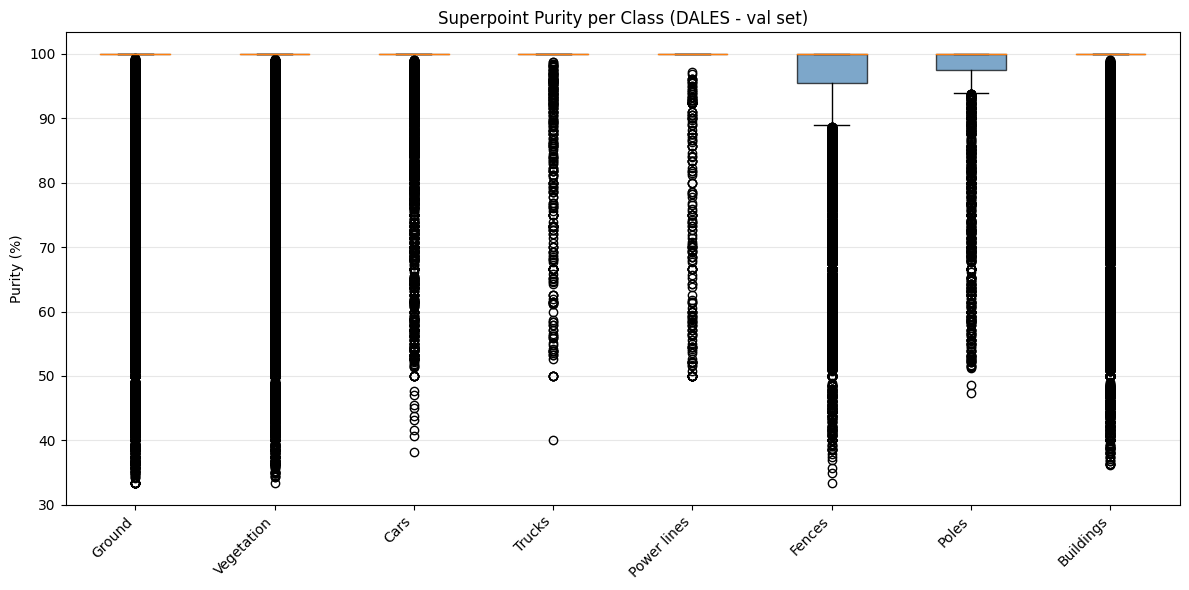

In [51]:
# Recompute purity with class labels
all_purities_cls = []
all_purity_class = []
all_purity_sizes_cls = []

for i in tqdm(range(len(dataset))):
    nag = dataset[i]
    super_index = nag[0].super_index.cpu().numpy()
    voxel_gt = nag[0].y.cpu().argmax(dim=1).numpy()
    num_sp = nag[1].num_points
    num_cls = num_classes + 1

    sp_class_counts = np.zeros((num_sp, num_cls), dtype=int)
    np.add.at(sp_class_counts, (super_index, voxel_gt), 1)

    sp_total = sp_class_counts.sum(axis=1)
    sp_max = sp_class_counts.max(axis=1)
    sp_majority = sp_class_counts.argmax(axis=1)

    nonzero = sp_total > 0
    all_purities_cls.append(sp_max[nonzero] / sp_total[nonzero])
    all_purity_class.append(sp_majority[nonzero])
    all_purity_sizes_cls.append(sp_total[nonzero])
    del nag

all_purities_cls = np.concatenate(all_purities_cls)
all_purity_class = np.concatenate(all_purity_class)
all_purity_sizes_cls = np.concatenate(all_purity_sizes_cls)

# Per-class purity table
print(f"\n{'Class':<15} | {'Mean purity':>12} | {'100% pure':>10} | {'<80% pure':>10} | {'Count':>8}")
print(f"{'-'*70}")
for cls_id in range(num_classes):
    cls_mask = all_purity_class == cls_id
    if cls_mask.sum() == 0:
        continue
    p = all_purities_cls[cls_mask]
    print(f"{DALES_CLASS_NAMES[cls_id]:<15} | {p.mean()*100:>11.2f}% | {(p==1.0).mean()*100:>9.1f}% | {(p<0.8).mean()*100:>9.1f}% | {cls_mask.sum():>8,}")

# Per-class purity boxplot
fig, ax = plt.subplots(figsize=(12, 6))
data_to_plot = []
labels_to_plot = []
for cls_id in range(num_classes):
    cls_mask = all_purity_class == cls_id
    if cls_mask.sum() > 0:
        data_to_plot.append(all_purities_cls[cls_mask] * 100)
        labels_to_plot.append(DALES_CLASS_NAMES[cls_id])

bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.set_ylabel('Purity (%)')
ax.set_title('Superpoint Purity per Class (DALES - val set)')
plt.xticks(rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('purity_per_class_dales.png', dpi=150, bbox_inches='tight')
plt.show()